GIFT cipher - It is a lightweight block cipher featuring an SPN (Substitution-Permutation Network) structure, designed to provide high hardware efficiency and security for resource-constrained devices. It improves upon older lightweight designs by using a more optimized bit-permutation layer and a 4-bit S-box to achieve better resistance against linear and differential cryptanalysis.

Logistic Regression

The features used in this model are the individual bits of two random plaintexts (P
1
​
 ,P
2
​
 ) and their bitwise XOR difference (ΔP=P
1
​
 ⊕P
2
​
 ), combined into a single vector. These initial bit features are then expanded using second-degree polynomial transformations to capture all two-way bit interactions, which helps the logistic regression model approximate the non-linear behavior of the cipher's S-boxes. This combined feature set is then used by the model to predict the bitwise XOR difference of the resulting ciphertexts (ΔC)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SBOX = [0x1, 0xA, 0x4, 0xC, 0x6, 0xF, 0x3, 0x9, 0x2, 0xD, 0xB, 0x7, 0x5, 0x0, 0x8, 0xE]
def sbox_layer(state):
    output = 0
    for i in range(8):
        nibble = (state >> (4*i)) & 0xF
        output |= SBOX[nibble] << (4*i)
    return output
def permute(state):
    bits = [int(b) for b in format(state, '032b')]
    perm = [0]*32
    for i in range(32):
        perm[(i * 5) % 32] = bits[i]
    return int("".join(map(str, perm)), 2)
def gift_encrypt(p, key, rounds):
    state = p
    for _ in range(rounds):
        state ^= (key & 0xFFFFFFFF)
        state = sbox_layer(state)
        state = permute(state)
    return state
def int_to_bits(x, bits=32):
    return [int(b) for b in format(x, f'0{bits}b')]

def generate_dataset(samples, rounds, key):
    X, Y = [], []
    for _ in range(samples):
        p1 = random.getrandbits(32)
        p2 = random.getrandbits(32)
        c1 = gift_encrypt(p1, key, rounds)
        c2 = gift_encrypt(p2, key, rounds)
        features = int_to_bits(p1) + int_to_bits(p2) + int_to_bits(p1 ^ p2)
        X.append(features)
        Y.append(int_to_bits(c1 ^ c2))
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

class LogisticRegressionGPU(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionGPU, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

def evaluate_gpu(X, Y):
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_poly = poly.fit_transform(X)

    X_train, X_test, Y_train, Y_test = train_test_split(
        X_poly, Y, test_size=0.2, random_state=42
    )

    X_train_t = torch.tensor(X_train).float()
    Y_train_t = torch.tensor(Y_train).float()
    X_test_t = torch.tensor(X_test).float().to(device)
    Y_test_t = torch.tensor(Y_test).float().to(device)

    train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=512, shuffle=True)

    model = LogisticRegressionGPU(X_train.shape[1], Y.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    model.train()
    for epoch in range(50):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t) > 0.5).float()
        accuracy = (preds == Y_test_t).float().mean().item()
        hamming = torch.mean(torch.sum(preds != Y_test_t, dim=1).float()).item()

    return accuracy, hamming

if __name__ == "__main__":
    key = random.getrandbits(64)
    samples = 20000 # Reduced slightly to prevent GPU OOM during Poly transformation

    for r in range(1, 6):
        print(f"\nRound {r} (GPU)")
        X, Y = generate_dataset(samples, r, key)
        acc, ham = evaluate_gpu(X, Y)
        print(f"Accuracy: {acc:.4f}")
        print(f"Hamming Distance: {ham:.4f}")


Round 1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Accuracy: 0.6037
Hamming Distance: 12.6820

Round 2
Accuracy: 0.5022
Hamming Distance: 15.9295

Round 3
Accuracy: 0.5016
Hamming Distance: 15.9502

Round 4
Accuracy: 0.4994
Hamming Distance: 16.0193

Round 5
Accuracy: 0.5015
Hamming Distance: 15.9525


GIFT+CNN

The CNN is organized into two sequential 1D convolutional layers (using 32 and 64 filters respectively) that extract local bit-level patterns and spatial dependencies from the 32-bit input state. These feature maps are then flattened and passed through a 128-unit dense hidden layer with ReLU activation, concluding with a 32-node output layer using a Sigmoid function to predict the bitwise probabilities of the ciphertext XOR difference.

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SBOX = [0x1, 0xA, 0x4, 0xC, 0x6, 0xF, 0x3, 0x9, 0x2, 0xD, 0xB, 0x7, 0x5, 0x0, 0x8, 0xE]

def sbox_layer(state):
    output = 0
    for i in range(8):
        nibble = (state >> (4*i)) & 0xF
        output |= SBOX[nibble] << (4*i)
    return output

def permute(state):
    bits = [int(b) for b in format(state, '032b')]
    perm = [0]*32
    for i in range(32):
        perm[(i * 5) % 32] = bits[i]
    return int("".join(map(str, perm)), 2)

def gift_encrypt(p, key, rounds):
    state = p
    for _ in range(rounds):
        state = (state ^ (key & 0xFFFFFFFF))
        state = sbox_layer(state)
        state = permute(state)
    return state

def int_to_bits(x, bits=32):
    return [int(b) for b in format(x, f'0{bits}b')]

def generate_dataset(samples, rounds, key):
    X, Y = [], []
    delta = 0x0000000F
    for _ in range(samples):
        p1 = random.getrandbits(32)
        p2 = p1 ^ delta
        c1 = gift_encrypt(p1, key, rounds)
        c2 = gift_encrypt(p2, key, rounds)
        X.append(int_to_bits(p1 ^ p2))
        Y.append(int_to_bits(c1 ^ c2))
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

class GiftCNN(nn.Module):
    def __init__(self):
        super(GiftCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 32, 128)
        self.fc2 = nn.Linear(128, 32)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

def train_model(X, Y):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )
    X_train = torch.tensor(X_train).unsqueeze(1)
    Y_train = torch.tensor(Y_train)
    X_test = torch.tensor(X_test).unsqueeze(1).to(device)
    Y_test = torch.tensor(Y_test).to(device)
    loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=512, shuffle=True)
    model = GiftCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    epochs = 15
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in loader:
            # MOVE BATCH TO GPU
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    model.eval()
    with torch.no_grad():
        preds = model(X_test)
        preds = (preds > 0.5).float()
        accuracy = (preds == Y_test).float().mean().item()
        hamming = torch.mean(torch.sum(preds != Y_test, dim=1).float()).item()

    return accuracy, hamming

if __name__ == "__main__":
    key = random.getrandbits(64)
    samples = 40000

    for r in range(1, 6):
        print(f"\nRound {r}")
        X, Y = generate_dataset(samples, r, key)
        acc, ham = train_model(X, Y)
        print(f"Accuracy: {acc:.4f} | Hamming: {ham:.4f}")

Using device: cuda

Round 1
Accuracy: 0.9375 | Hamming: 1.9994

Round 2
Accuracy: 0.8443 | Hamming: 4.9820

Round 3
Accuracy: 0.7075 | Hamming: 9.3606

Round 4
Accuracy: 0.5755 | Hamming: 13.5843

Round 5
Accuracy: 0.5123 | Hamming: 15.6078


GIFT + MLP

The Multi-Layer Perceptron (MLP) model you implemented is a fully connected neural network consisting of two hidden layers with 128 units each and ReLU activations. It serves as a non-linear baseline to approximate the GIFT cipher's behavior by mapping input bit differences to output ciphertext XOR differences. The architecture concludes with a Sigmoid output layer to produce bitwise probabilities, allowing for the evaluation of learning degradation across increasing encryption rounds

In [ ]:
from torch._C import default_generator
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SBOX = [0x1, 0xA, 0x4, 0xC, 0x6, 0xF, 0x3, 0x9, 0x2, 0xD, 0xB, 0x7, 0x5, 0x0, 0x8, 0xE]
def sbox_layer(state):
    output = 0
    for i in range(8):
        nibble = (state >> (4*i)) & 0xF
        output |= SBOX[nibble] << (4*i)
    return output

def permute(state):
    bits = [int(b) for b in format(state, '032b')]
    perm = [0]*32
    for i in range(32): perm[(i * 5) % 32] = bits[i]
    return int("".join(map(str, perm)), 2)

def gift_encrypt(p, key, rounds):
    state = p
    for _ in range(rounds):
        state = permute(sbox_layer(state ^ (key & 0xFFFFFFFF)))
    return state

def int_to_bits(x, bits=32): return [int(b) for b in format(x, f'0{bits}b')]

def generate_dataset(samples, rounds, key):
    X, Y = [], []
    delta = 0x0000000F
    for _ in range(samples):
        p1 = random.getrandbits(32)
        p2 = p1 ^ default_generator
        X.append(int_to_bits(p1 ^ p2))
        dc = gift_encrypt(p1, key, rounds) ^ gift_encrypt(p2, key, rounds)
        Y.append(int_to_bits(dc))
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

class GiftMLP(nn.Module):
    def __init__(self, input_dim=32, output_dim=32):
        super(GiftMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x): return self.layers(x)

# 3. Training Function (Updated for Hamming Distance)
def train_and_save(X, Y, round_num):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train)), batch_size=512, shuffle=True)
    X_test_t = torch.tensor(X_test).to(device)
    Y_test_t = torch.tensor(Y_test).to(device)

    model = GiftMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    for epoch in range(20):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    torch.save(model.state_dict(), f"gift_mlp_r{round_num}.pth")
    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t) > 0.5).float()

        acc = (preds == Y_test_t).float().mean().item()

        hamming = torch.mean(torch.sum(preds != Y_test_t, dim=1).float()).item()

    return acc, hamming

if __name__ == "__main__":
    key = random.getrandbits(64)
    print(f"Using device: {device}")

    for r in range(1, 6):
        X, Y = generate_dataset(40000, r, key)
        acc, ham = train_and_save(X, Y, r)
        print(f"Round {r} | Accuracy: {acc:.4f} | Hamming: {ham:.4f}")

Using device: cuda
Round 1 | Accuracy: 0.9379 | Hamming: 1.9858
Round 2 | Accuracy: 0.8434 | Hamming: 5.0124
Round 3 | Accuracy: 0.7068 | Hamming: 9.3818
Round 4 | Accuracy: 0.5783 | Hamming: 13.4956
Round 5 | Accuracy: 0.5143 | Hamming: 15.5439


Generalization

Using device: cuda

Round      | Gen Accuracy    | Hamming Distance  
--------------------------------------------------
Round 1     | 0.9377        | 1.9926
Round 2     | 0.8443        | 4.9838
Round 3     | 0.7094        | 9.2977
Round 4     | 0.5794        | 13.4599
Round 5     | 0.5128        | 15.5898


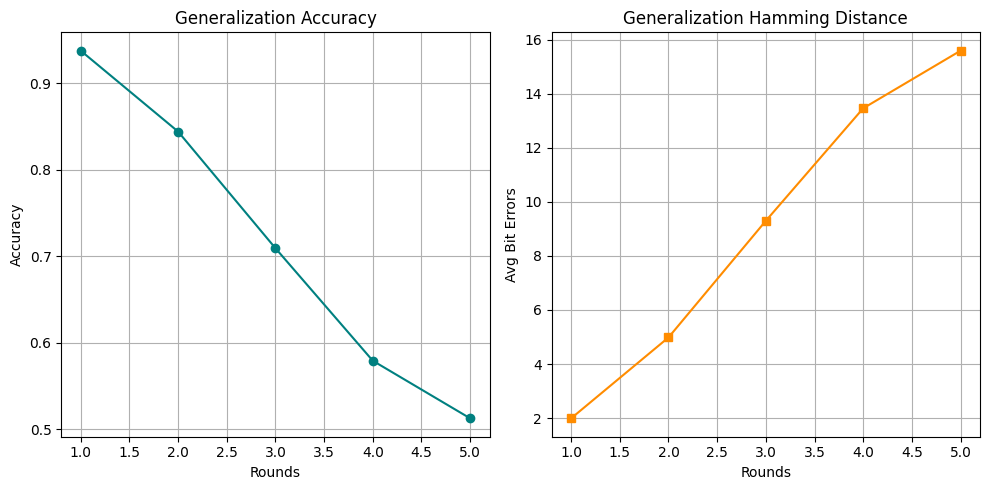

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class GiftMLP(nn.Module):
    def __init__(self, input_dim=32, output_dim=32):
        super(GiftMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x): return self.layers(x)

SBOX = [0x1, 0xA, 0x4, 0xC, 0x6, 0xF, 0x3, 0x9, 0x2, 0xD, 0xB, 0x7, 0x5, 0x0, 0x8, 0xE]
def sbox_layer(state):
    output = 0
    for i in range(8):
        nibble = (state >> (4*i)) & 0xF
        output |= SBOX[nibble] << (4*i)
    return output

def permute(state):
    bits = [int(b) for b in format(state, '032b')]
    perm = [0]*32
    for i in range(32): perm[(i * 5) % 32] = bits[i]
    return int("".join(map(str, perm)), 2)

def gift_encrypt(p, key, rounds):
    state = p
    for _ in range(rounds):
        state = permute(sbox_layer(state ^ (key & 0xFFFFFFFF)))
    return state

def int_to_bits(x, bits=32): return [int(b) for b in format(x, f'0{bits}b')]

def generate_unseen_dataset(samples, rounds, key):
    X, Y = [], []
    delta = 0x0000000F
    for _ in range(samples):
        p1 = random.getrandbits(32)
        p2 = p1 ^ delta
        X.append(int_to_bits(p1 ^ p2))
        dc = gift_encrypt(p1, key, rounds) ^ gift_encrypt(p2, key, rounds)
        Y.append(int_to_bits(dc))
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

def run_generalization():
    rounds = range(1, 6)
    gen_accs = []
    gen_hammings = []
    success_rounds = []

    test_key = random.getrandbits(64)

    print(f"\n{'Round':<10} | {'Gen Accuracy':<15} | {'Hamming Distance':<18}")
    print("-" * 50)

    for r in rounds:
        model_path = f"gift_mlp_r{r}.pth"

        if os.path.exists(model_path):
            try:
                X_gen, Y_gen = generate_unseen_dataset(10000, r, test_key)

                X_t = torch.tensor(X_gen).to(device)
                Y_t = torch.tensor(Y_gen).to(device)

                model = GiftMLP().to(device)
                model.load_state_dict(torch.load(model_path, map_location=device))
                model.eval()

                with torch.no_grad():
                    preds = (model(X_t) > 0.5).float()

                    acc = (preds == Y_t).float().mean().item()

                    hamming = torch.mean(torch.sum(preds != Y_t, dim=1).float()).item()

                    gen_accs.append(acc)
                    gen_hammings.append(hamming)
                    success_rounds.append(r)

                    print(f"Round {r:<5} | {acc:.4f}        | {hamming:.4f}")

            except Exception as e:
                print(f"Round {r:<5} | Error: {e}")
        else:
            print(f"Round {r:<5} | Model file {model_path} not found.")

    if gen_accs:
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.plot(success_rounds, gen_accs, marker='o', color='teal')
        plt.title("Generalization Accuracy")
        plt.xlabel("Rounds"); plt.ylabel("Accuracy")
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(success_rounds, gen_hammings, marker='s', color='darkorange')
        plt.title("Generalization Hamming Distance")
        plt.xlabel("Rounds"); plt.ylabel("Avg Bit Errors")
        plt.grid(True)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    run_generalization()